In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [34]:
# =========================================================
# LOAD CLEAN DATASET
# =========================================================

df = pd.read_excel("final_df.xlsx")

In [35]:
# =========================================================
# DATASET OVERVIEW
# =========================================================

print(df.shape)

df.head()

(12377, 41)


,vaccinated,vaccinated_5class,vaccinated_9class,antenatal_visits_yes,institutional_delivery,birth_order,mothers_age_gt_35,residence_urban,media_exposure,child_age_months,highest_educational_level,wealth_index,recieves_icds_benefits,facility_distance_issue,has_automobile,health_worker_visit,bcg,dpt1,polio1,dpt2,polio2,dpt3,polio3,measles1,pentavalent1,pentavalent2,pentavalent3,state,respondent_age,antenatal_visits,place_of_delivery,child_sex,has_motorcycle,has_car_truck,reads_newspaper,listens_radio,watches_tv,household_sex_female,sample_weight,psu,strata
0,1,4,8,1,1,4,0,0,0,13,1,3,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,35,5,21,2,0,0,0,0,0,0,196628,109,121
1,1,4,8,1,1,2,0,0,1,12,2,5,0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,30,8,21,2,0,1,0,1,1,0,204798,140,121
2,1,4,8,1,1,3,1,0,0,12,2,3,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,37,10,24,1,0,0,0,0,0,0,220211,102,121
3,1,4,8,1,1,1,0,0,0,16,2,4,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,27,7,21,2,0,1,0,0,0,0,303213,133,122
4,1,4,8,1,1,2,0,0,1,20,0,2,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,34,10,21,1,0,0,0,1,0,0,352749,118,123


In [36]:
# =========================================================
# DATASET INFORMATION
# =========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12377 entries, 0 to 12376
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   vaccinated                 12377 non-null  int64
 1   vaccinated_5class          12377 non-null  int64
 2   vaccinated_9class          12377 non-null  int64
 3   antenatal_visits_yes       12377 non-null  int64
 4   institutional_delivery     12377 non-null  int64
 5   birth_order                12377 non-null  int64
 6   mothers_age_gt_35          12377 non-null  int64
 7   residence_urban            12377 non-null  int64
 8   media_exposure             12377 non-null  int64
 9   child_age_months           12377 non-null  int64
 10  highest_educational_level  12377 non-null  int64
 11  wealth_index               12377 non-null  int64
 12  recieves_icds_benefits     12377 non-null  int64
 13  facility_distance_issue    12377 non-null  int64
 14  has_automobile        

In [37]:
# =========================================================
# MISSING VALUE ANALYSIS
# =========================================================

df.isnull().sum()

vaccinated                   0
vaccinated_5class            0
vaccinated_9class            0
antenatal_visits_yes         0
institutional_delivery       0
birth_order                  0
mothers_age_gt_35            0
residence_urban              0
media_exposure               0
child_age_months             0
highest_educational_level    0
wealth_index                 0
recieves_icds_benefits       0
facility_distance_issue      0
has_automobile               0
health_worker_visit          0
bcg                          0
dpt1                         0
polio1                       0
dpt2                         0
polio2                       0
dpt3                         0
polio3                       0
measles1                     0
pentavalent1                 0
pentavalent2                 0
pentavalent3                 0
state                        0
respondent_age               0
antenatal_visits             0
place_of_delivery            0
child_sex                    0
has_moto

In [38]:
# =========================================================
# TARGET VARIABLE DISTRIBUTION
# =========================================================

counts = df["vaccinated"].value_counts()

percent = df["vaccinated"].value_counts(
    normalize=True
)

result = pd.concat(

    [counts, percent],

    axis=1,

    keys=['Count', 'Percentage']
)

result

,Count,Percentage
vaccinated,,
1,7804,0.630524
0,4573,0.369476


In [39]:
# =========================================================
# SELECTED FEATURES
# =========================================================

features = [

    'antenatal_visits_yes',
    'institutional_delivery',
    'birth_order',
    'mothers_age_gt_35',
    'residence_urban',
    'media_exposure',
    'child_age_months',
    'highest_educational_level',
    'wealth_index',
    'recieves_icds_benefits',
    'facility_distance_issue',
    'has_automobile',
    'health_worker_visit'
]

target = 'vaccinated'

df_model = df[features + [target]]

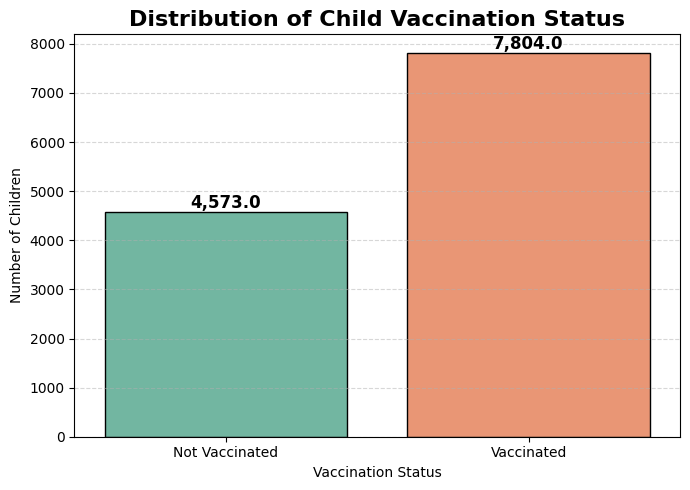

In [40]:
# =========================================================
# VACCINATION STATUS DISTRIBUTION
# =========================================================

plt.figure(figsize=(7,5))

ax = sns.countplot(

    x='vaccinated',

    data=df_model,

    palette='Set2',

    edgecolor='black'
)

for p in ax.patches:

    height = p.get_height()

    ax.annotate(

        f'{height:,}',

        (
            p.get_x() + p.get_width()/2,
            height
        ),

        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    "Distribution of Child Vaccination Status",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Vaccination Status")

plt.ylabel("Number of Children")

ax.set_xticklabels([

    'Not Vaccinated',
    'Vaccinated'
])

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

In [41]:
# =========================================================
# DISTRIBUTION OF KEY VARIABLES
# =========================================================

eda_vars = [

    'vaccinated',

    'antenatal_visits_yes',

    'institutional_delivery',

    'birth_order',

    'mothers_age_gt_35',

    'residence_urban',

    'media_exposure',

    'highest_educational_level',

    'wealth_index',

    'recieves_icds_benefits',

    'facility_distance_issue',

    'has_automobile',

    'health_worker_visit'
]

for col in eda_vars:

    print("\n" + "="*50)

    print(f"Distribution of: {col}")

    print("="*50)

    counts = df[col].value_counts()

    percent = (

        df[col]
        .value_counts(normalize=True) * 100

    ).round(2)

    summary = pd.DataFrame({

        'Frequency': counts,

        'Percentage (%)': percent
    })

    print(summary)


Distribution of: vaccinated
            Frequency  Percentage (%)
vaccinated                           
1                7804           63.05
0                4573           36.95

Distribution of: antenatal_visits_yes
                      Frequency  Percentage (%)
antenatal_visits_yes                           
1                          6500           52.52
0                          5877           47.48

Distribution of: institutional_delivery
                        Frequency  Percentage (%)
institutional_delivery                           
1                           10193           82.35
0                            2184           17.65

Distribution of: birth_order
             Frequency  Percentage (%)
birth_order                           
2                 3699           29.89
1                 3475           28.08
3                 2576           20.81
4                 1389           11.22
5                  721            5.83
6                  315            2.55
7    

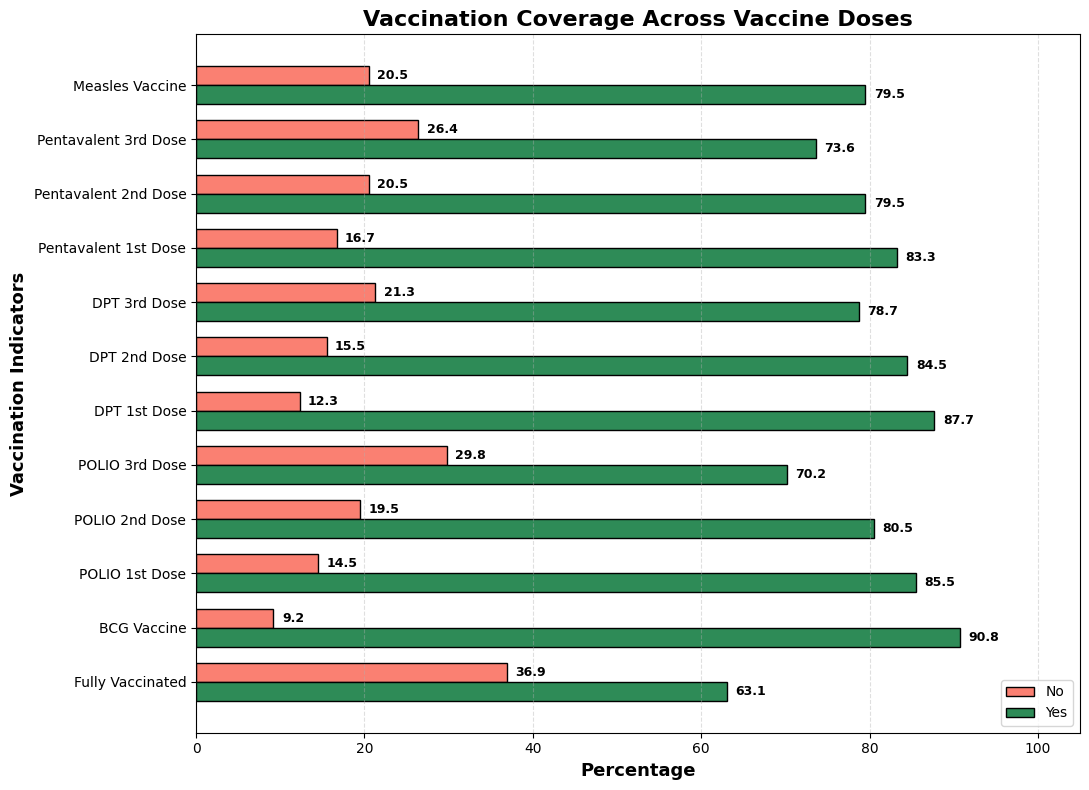

In [42]:
# =========================================================
# VACCINATION COVERAGE ACROSS VACCINE DOSES
# =========================================================

vaccine_cols = [

    'vaccinated',

    'bcg',

    'polio1',
    'polio2',
    'polio3',

    'dpt1',
    'dpt2',
    'dpt3',

    'pentavalent1',
    'pentavalent2',
    'pentavalent3',

    'measles1'
]

labels = [

    'Fully Vaccinated',

    'BCG Vaccine',

    'POLIO 1st Dose',
    'POLIO 2nd Dose',
    'POLIO 3rd Dose',

    'DPT 1st Dose',
    'DPT 2nd Dose',
    'DPT 3rd Dose',

    'Pentavalent 1st Dose',
    'Pentavalent 2nd Dose',
    'Pentavalent 3rd Dose',

    'Measles Vaccine'
]

# Calculate percentages
yes_percent = []
no_percent = []

for col in vaccine_cols:

    yes = df[col].mean() * 100

    no = 100 - yes

    yes_percent.append(round(yes,1))

    no_percent.append(round(no,1))

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(11,8))

y = np.arange(len(labels))

bar_height = 0.35

# NO bars
plt.barh(
    y + bar_height/2,
    no_percent,
    height=bar_height,
    color='salmon',
    edgecolor='black',
    label='No'
)

# YES bars
plt.barh(
    y - bar_height/2,
    yes_percent,
    height=bar_height,
    color='seagreen',
    edgecolor='black',
    label='Yes'
)

# Add percentage labels
for i in range(len(labels)):

    plt.text(
        yes_percent[i] + 1,
        i - bar_height/2,
        f"{yes_percent[i]}",
        va='center',
        fontsize=9,
        fontweight='bold'
    )

    plt.text(
        no_percent[i] + 1,
        i + bar_height/2,
        f"{no_percent[i]}",
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# Axes labels
plt.yticks(
    y,
    labels,
    fontsize=10
)

plt.xlabel(
    "Percentage",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Vaccination Indicators",
    fontsize=13,
    fontweight='bold'
)

# Title
plt.title(
    "Vaccination Coverage Across Vaccine Doses",
    fontsize=16,
    fontweight='bold'
)

# Legend
plt.legend(
    loc='lower right',
    fontsize=10
)

# Grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.xlim(0, 105)

plt.tight_layout()

plt.show()

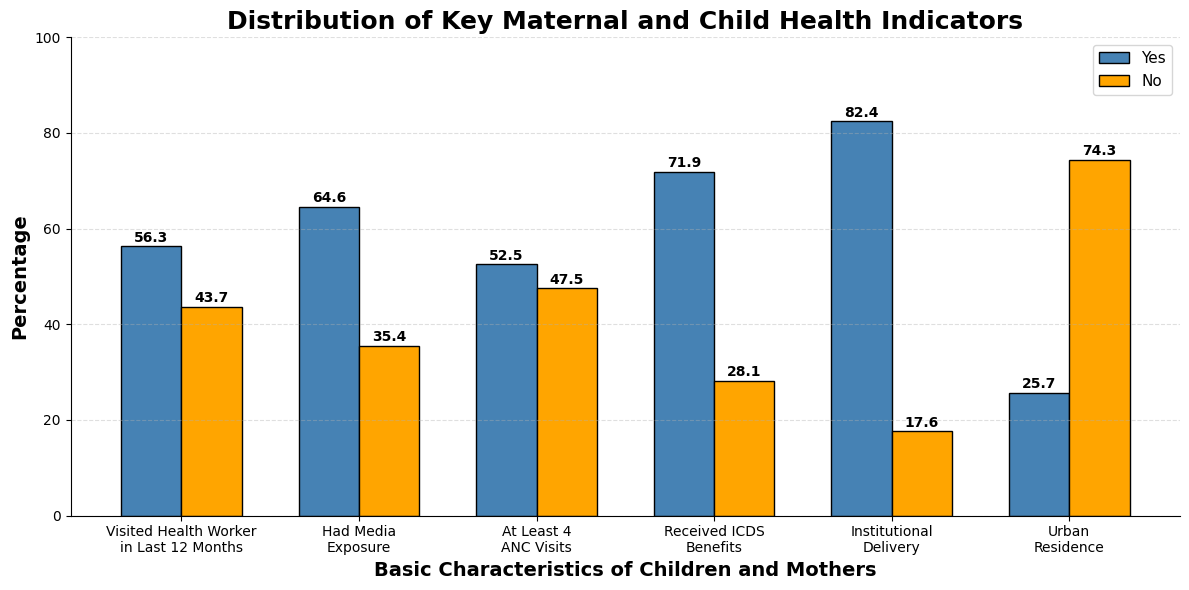

In [43]:
# =========================================================
# MATERNAL AND CHILD HEALTH INDICATORS
# =========================================================

selected_vars = [

    'health_worker_visit',

    'media_exposure',

    'antenatal_visits_yes',

    'recieves_icds_benefits',

    'institutional_delivery',

    'residence_urban'
]

labels = [

    'Visited Health Worker\nin Last 12 Months',

    'Had Media\nExposure',

    'At Least 4\nANC Visits',

    'Received ICDS\nBenefits',

    'Institutional\nDelivery',

    'Urban\nResidence'
]

# Calculate percentages
yes_percent = []
no_percent = []

for col in selected_vars:

    yes = df[col].mean() * 100

    no = 100 - yes

    yes_percent.append(round(yes,1))

    no_percent.append(round(no,1))

# =========================================================
# BAR POSITIONS
# =========================================================

x = np.arange(len(labels))

width = 0.34

# =========================================================
# FIGURE
# =========================================================

plt.figure(figsize=(12,6))

# YES bars
bars1 = plt.bar(

    x - width/2,

    yes_percent,

    width,

    color='steelblue',

    edgecolor='black',

    label='Yes'
)

# NO bars
bars2 = plt.bar(

    x + width/2,

    no_percent,

    width,

    color='orange',

    edgecolor='black',

    label='No'
)

# Add value labels
for bar in bars1:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 1,

        f'{height:.1f}',

        ha='center',

        fontsize=10,

        fontweight='bold'
    )

for bar in bars2:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 1,

        f'{height:.1f}',

        ha='center',

        fontsize=10,

        fontweight='bold'
    )

# Axes labels
plt.xticks(

    x,

    labels,

    fontsize=10
)

plt.ylabel(

    "Percentage",

    fontsize=14,

    fontweight='bold'
)

plt.xlabel(

    "Basic Characteristics of Children and Mothers",

    fontsize=14,

    fontweight='bold'
)

# Title
plt.title(

    "Distribution of Key Maternal and Child Health Indicators",

    fontsize=18,

    fontweight='bold'
)

# Legend
plt.legend(
    fontsize=11
)

# Grid
plt.grid(

    axis='y',

    linestyle='--',

    alpha=0.4
)

plt.ylim(0, 100)

sns.despine()

plt.tight_layout()

plt.show()

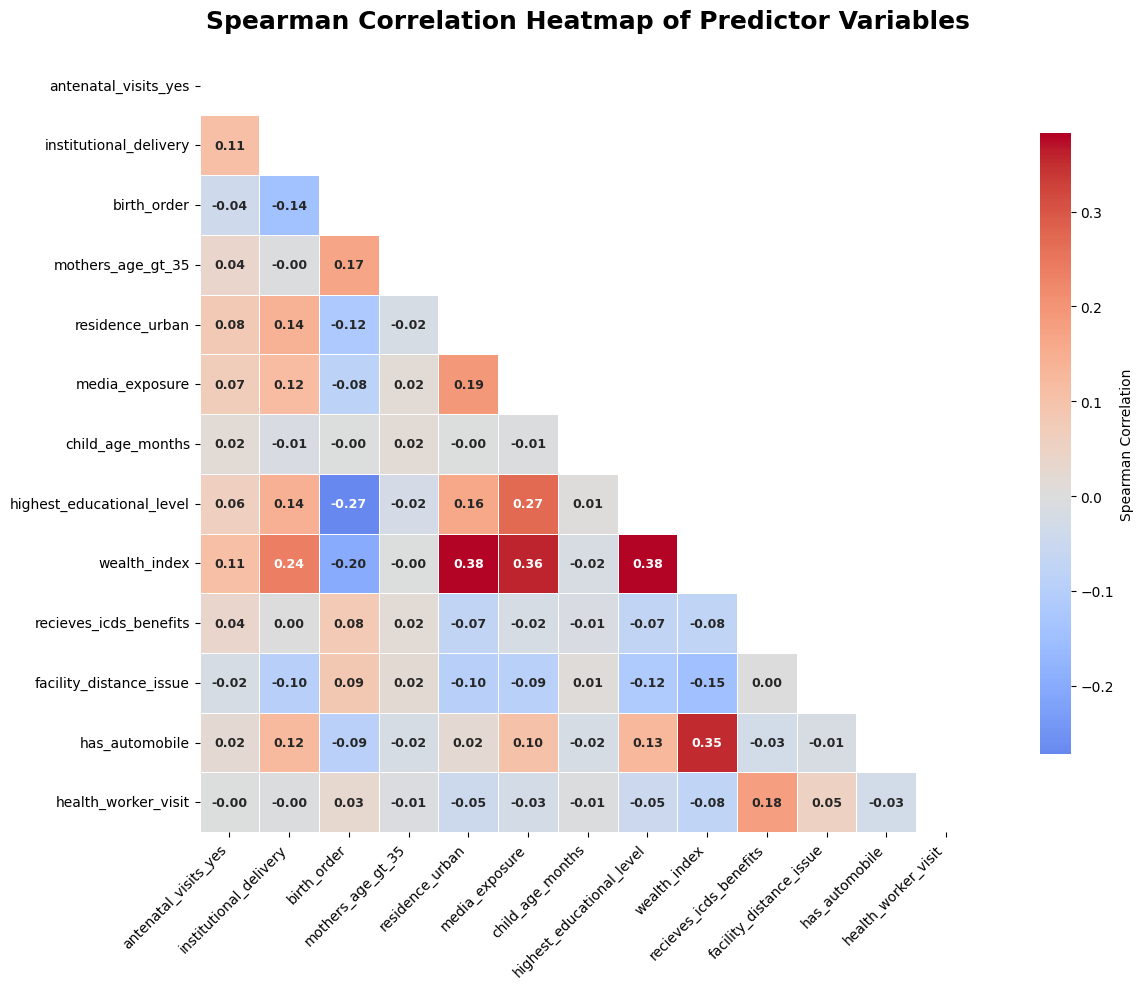

In [44]:
# =========================================================
# SPEARMAN CORRELATION MATRIX
# =========================================================

corr = df_model[features].corr(method='spearman')

# =========================================================
# MASK UPPER TRIANGLE
# =========================================================

mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14,10))

heatmap = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={
        'shrink': 0.8,
        'label': 'Spearman Correlation'
    },
    annot_kws={
        'size': 9,
        'weight': 'bold'
    }
)

# =========================================================
# TITLES & LABELS
# =========================================================

plt.title(
    "Spearman Correlation Heatmap of Predictor Variables",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()

plt.show()

In [45]:
# =========================================================
# CHI-SQUARE TEST
# =========================================================

results = []

for col in features:

    table = pd.crosstab(

        df_model[col],

        df_model['vaccinated']
    )

    chi2, p, dof, expected = chi2_contingency(table)

    results.append({

        'Variable': col,

        'Chi_square': chi2,

        'P_value': p
    })

chi_df = pd.DataFrame(results)

chi_df

,Variable,Chi_square,P_value
0,antenatal_visits_yes,1091.983216,1.825126e-239
1,institutional_delivery,510.644864,4.591037e-113
2,birth_order,197.268551,5.989191e-37
3,mothers_age_gt_35,448.365520,1.636158e-99
4,residence_urban,157.824551,3.380473e-36
5,media_exposure,225.056525,7.136446e-51
6,child_age_months,248.445045,5.912609e-47
7,highest_educational_level,104.730255,1.493410e-22
8,wealth_index,835.813831,1.341066e-179
9,recieves_icds_benefits,967.088835,2.559097e-212


In [46]:
# =========================================================
# VARIANCE INFLATION FACTOR
# =========================================================

X_vif = df_model[features]

vif_df = pd.DataFrame()

vif_df["Variable"] = X_vif.columns

vif_df["VIF"] = [

    variance_inflation_factor(
        X_vif.values, i
    )

    for i in range(X_vif.shape[1])
]

vif_df

,Variable,VIF
0,antenatal_visits_yes,2.149382
1,institutional_delivery,5.689209
2,birth_order,4.099409
3,mothers_age_gt_35,1.124058
4,residence_urban,1.633961
5,media_exposure,3.321026
6,child_age_months,12.125994
7,highest_educational_level,3.607343
8,wealth_index,7.954372
9,recieves_icds_benefits,3.562208


In [47]:
# =========================================================
# FINAL EDA SUMMARY
# =========================================================

print("Dataset Shape:", df.shape)

print("\nTarget Variable Distribution:\n")

print(df["vaccinated"].value_counts())

Dataset Shape: (12377, 41)

Target Variable Distribution:

vaccinated
1    7804
0    4573
Name: count, dtype: int64
